In [34]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

# Deep Neural Network
## Lecture 08: Intro to tensorflow

### Wines dataset


## Import Statements

In [35]:
###-----------------
### Import Libraries
###-----------------

import os
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split    # for train-test splitting
from sklearn.preprocessing import StandardScaler, LabelEncoder        # for accuracy score calculation
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                                   ConfusionMatrixDisplay, f1_score)        # for classification report and confusion matrix

import tensorflow as tf

In [36]:
# input and output directories
inpDir = '../../input'
outDir = '../output'

# some global variables

RANDOM_STATE = 24
np.random.RandomState(seed=RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Hyperparameters
EPOCHS     = 100 # Number of iterations
TEST_SIZE  = 0.2 # Size of test data
ALPHA      = 0.001 # Learning rate 

In [37]:
# are there any GPUs available?
physical_devices = tf.config.list_physical_devices('GPU')

# if there are, set memory growth to True (prevents TensorFlow from allocating all GPU memory)
if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)

# Load Data

In [38]:
data_df = pd.read_csv(r"..\..\SharedData\wine.csv", header=None)
data_df.head()


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


In [39]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       178 non-null    float64
 1   1       178 non-null    float64
 2   2       178 non-null    float64
 3   3       178 non-null    float64
 4   4       178 non-null    int64  
 5   5       178 non-null    float64
 6   6       178 non-null    float64
 7   7       178 non-null    float64
 8   8       178 non-null    float64
 9   9       178 non-null    float64
 10  10      178 non-null    float64
 11  11      178 non-null    float64
 12  12      178 non-null    int64  
 13  13      178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [40]:
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
0,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
1,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
2,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
3,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
4,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
5,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
6,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
7,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
8,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
9,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


<Axes: >

<Axes: >

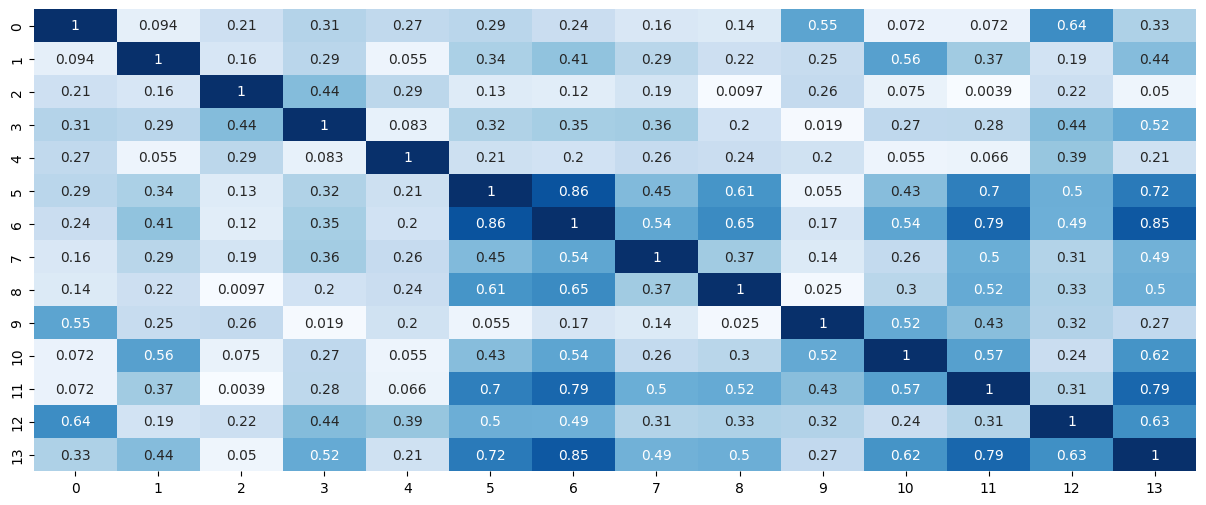

In [41]:
fig, ax = plt.subplots(figsize=(15, 6))

sns.heatmap(data_df.corr().abs(), annot=True, fmt='.2g', 
            cmap='Blues', ax=ax, cbar=False)

In [42]:
for col in data_df.columns:
    print(f"{col}: {data_df[col].nunique()} -  {data_df[col].unique()}")

0: 126 -  [14.23 13.2  13.16 14.37 13.24 14.2  14.39 14.06 14.83 13.86 14.1  14.12
 13.75 14.75 14.38 13.63 14.3  13.83 14.19 13.64 12.93 13.71 12.85 13.5
 13.05 13.39 13.3  13.87 14.02 13.73 13.58 13.68 13.76 13.51 13.48 13.28
 13.07 14.22 13.56 13.41 13.88 14.21 13.9  13.94 13.82 13.77 13.74 13.29
 13.72 12.37 12.33 12.64 13.67 12.17 13.11 13.34 12.21 12.29 13.49 12.99
 11.96 11.66 13.03 11.84 12.7  12.   12.72 12.08 12.67 12.16 11.65 11.64
 12.69 11.62 12.47 11.81 12.6  12.34 11.82 12.51 12.42 12.25 12.22 11.61
 11.46 12.52 11.76 11.41 11.03 12.77 11.45 11.56 11.87 12.07 12.43 11.79
 12.04 12.86 12.88 12.81 12.53 12.84 13.36 13.52 13.62 12.87 13.32 13.08
 12.79 13.23 12.58 13.17 13.84 12.45 14.34 12.36 13.69 12.96 13.78 13.45
 12.82 13.4  12.2  14.16 13.27 14.13]
1: 133 -  [1.71 1.78 2.36 1.95 2.59 1.76 1.87 2.15 1.64 1.35 2.16 1.48 1.73 1.81
 1.92 1.57 1.59 3.1  1.63 3.8  1.86 1.6  2.05 1.77 1.72 1.9  1.68 1.5
 1.66 1.83 1.53 1.8  1.65 3.99 3.84 1.89 3.98 4.04 3.59 2.02 1.75 1.67
 

In [43]:
labels=data_df[data_df.columns[-1]]
features=data_df.drop(columns=data_df.columns[-1])
features.shape, labels.shape

((178, 13), (178,))

In [44]:
X_train,X_test,y_train,y_test = train_test_split(features,labels,
                                                 test_size=TEST_SIZE,
                                                 random_state=RANDOM_STATE,
                                                 stratify=labels)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((142, 13), (142,), (36, 13), (36,))

In [45]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [46]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [47]:
print(sys.float_info.max), print(sys.float_info.min)
print(np.log(sys.float_info.max))
print(np.exp(710))  # overflow
print(np.exp(709))  

1.7976931348623157e+308
2.2250738585072014e-308
709.782712893384
inf
8.218407461554972e+307


1.7976931348623157e+308
2.2250738585072014e-308
709.782712893384
inf
8.218407461554972e+307


C:\Users\PGCP-AI\AppData\Local\Temp\ipykernel_13860\2189277204.py:3: RuntimeWarning: overflow encountered in exp
  print(np.exp(710))  # overflow


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(features.shape[1],)),
    tf.keras.layers.Dense(8, activation='relu'),   # default linear activation
    tf.keras.layers.Dense(len(le.classes_))
])

In [49]:
X_train[:1]

array([[-0.02222104, -0.61751924,  0.85197806,  3.13822833,  2.89556415,
         1.63549206,  0.86441875, -1.2103246 ,  0.59041704, -0.74138556,
         1.52983005,  1.27292302,  0.73966546]])

In [50]:
prediction = model(X_train[:1]).numpy()

In [51]:
tf.nn.softmax(prediction).numpy().sum()

np.float32(1.0)

In [52]:
model.summary()

Model: "sequential_2"

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 8)              │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 8)              │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 139 (556.00 B)

 Trainable params: 139 (556.00 B)

 Non-trainable params: 0 (0.00 B)

In [53]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=ALPHA)

In [54]:
model.compile(
    optimizer=optimizer, 
    loss=loss_fn, 
    metrics=['accuracy']
    )

In [55]:
history = model.fit(X_train, y_train, 
                    epochs=EPOCHS, 
                    validation_data=[X_test, y_test]
                    )

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.3732 - loss: 1.2227 - val_accuracy: 0.3889 - val_loss: 1.2574
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3803 - loss: 1.1890 - val_accuracy: 0.4167 - val_loss: 1.2200
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4155 - loss: 1.1573 - val_accuracy: 0.4167 - val_loss: 1.1842
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4296 - loss: 1.1266 - val_accuracy: 0.4722 - val_loss: 1.1488
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4507 - loss: 1.0967 - val_accuracy: 0.4722 - val_loss: 1.1140
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5000 - loss: 1.0676 - val_accuracy: 0.5000 - val_loss: 1.0804
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5000 - loss: 1.0389 - val_accuracy: 0.5278 - val_loss: 1.0476
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5141 - loss: 1.0108 - val_accuracy: 0.5556 - val_loss:

In [56]:
loss_df = pd.DataFrame(history.history)
loss_df.head()

,accuracy,loss,val_accuracy,val_loss
0,0.373239,1.222684,0.388889,1.257379
1,0.380282,1.189046,0.416667,1.220044
2,0.415493,1.157303,0.416667,1.184190
3,0.429577,1.126616,0.472222,1.148805
4,0.450704,1.096735,0.472222,1.114044


In [57]:
y_pred = model.predict(X_test)
accuracy_score = accuracy_score(y_test, y_pred.argmax(axis=1))
print(accuracy_score)
loss_df.iloc[-1][loss_df.columns[1]]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
0.9444444444444444


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
0.9444444444444444


np.float64(0.0837261825799942)

In [ ]:
def fn_plot_tf_hist(hist_df):
    fig,axes=plt.subplots(1,2,figsize=(15,6))
    props = dict(boxstyle='round', facecolor='aqua', alpha=0.4)
    
    facecolor='cyan'
    fontsize=12
    cmap=plt.cm.coolwarm
    
     # Get columns by index to eliminate any column naming error
    y1 = hist_df.columns[0]
    y2 = hist_df.columns[1]
    y3 = hist_df.columns[2]
    y4 = hist_df.columns[3]
    
    best = hist_df[hist_df['val_loss']==hist_df['val_loss'].min()]
    
    best_idx = best.index.to_numpy()[0]
    best_loss = best['val_loss'].to_numpy()[0]
    
    ax = axes[0]
    loss_df[['loss', 'val_loss']].plot(ax=ax,colormap=cmap)
    
    txtFmt = 'Loss:\n train:{:6.4f}\n test:{:6.4f}'
    
    txtstr = txtFmt.format(hist_df.iloc[-1]['loss'], 
                           hist_df.iloc[-1]['val_loss'])
    
    ax.text(0.3, 0.95, txtstr, transform=ax.transAxes, fontsize=fontsize,
           verticalalignment='top', bbox=props)
    
    ax.annotate(f'Min:{best_loss}', xy = {best_idx, best_loss},
                xytext = (best_idx, best_loss+0.1), fontsize = fontsize,
                bbox = props, arrowprops = dict(facecolor = facecolor, shrink=0.05))
    
    ax.axvline(x = best_idx, color = 'green', lw=3, linestyle= '-.')
    
    
    ax = axes[1]
    best_acc = best['val_accuracy'].to_numpy()[0]
    
    hist_df[['accuracy', 'val_accuracy']].plot(ax=ax, colormap=cmap)
    
    txtfmt = 'Accuracy:\n train:{:6.4f}\n test:{:6.4f}'
    
    txtstr = txtfmt.format(hist_df.iloc[-1]['accuracy'], 
                           hist_df.iloc[-1]['val_accuracy'])
    
    ax.text(0.3, 0.95, txtstr, transform=ax.transAxes, fontsize=fontsize,
           verticalalignment='top', bbox=props)
    
    ax.annotate(f'Min:{best_acc}', xy = {best_idx, best_acc},
                xytext = (best_idx, best_acc+0.1), fontsize = fontsize,
                bbox = props, arrowprops = dict(facecolor = facecolor, shrink=0.05))
    
    ax.axvline(x = best_idx, color = 'green', lw=3, linestyle= '-.')

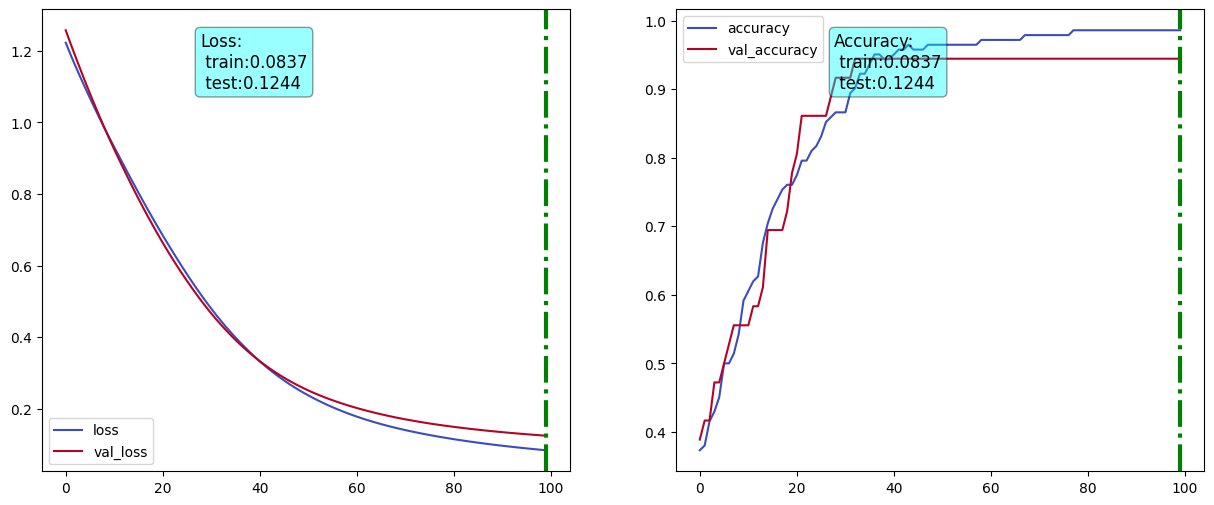

In [59]:
fn_plot_tf_hist(loss_df)

In [60]:
loss_df[loss_df['val_loss'] == loss_df['val_loss'].min()]

,accuracy,loss,val_accuracy,val_loss
99,0.985915,0.083726,0.944444,0.124412


# Predictions

In [65]:
prob_model = tf.keras.Sequential([model,
                                  tf.keras.layers.Softmax()])

In [69]:
from sklearn.metrics import accuracy_score

y_predict = prob_model(X_train).numpy()
print(y_predict.shape)

accuracy_score(y_train, y_predict.argmax(axis=1))

(142, 3)


0.9859154929577465

In [ ]:
print(classification_report(y_train, y_predict.argmax(axis=1)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        47
           1       1.00      0.98      0.99        57
           2       0.97      1.00      0.99        38

    accuracy                           0.99       142
   macro avg       0.99      0.99      0.99       142
weighted avg       0.99      0.99      0.99       142



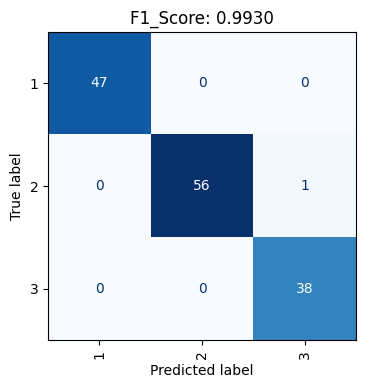

In [ ]:
cm = confusion_matrix(y_train, y_predict.argmax(axis=1))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1,2,3])

fig, ax = plt.subplots(figsize = (4,4))

disp.plot(ax=ax, cmap='Blues',  xticks_rotation = 'vertical', colorbar=False)
# Disable the grid
ax.grid(False)
ax.set_title(f"F1_Score: {f1_score(y_train,y_predict.argmax(axis=1), average='weighted'):0.4f}")
plt.show()

In [70]:
y_predict = prob_model(X_test).numpy()

display(accuracy_score(y_test, y_predict.argmax(axis=1)))

print(classification_report(y_test, y_predict.argmax(axis=1)))

0.9444444444444444

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       1.00      0.86      0.92        14
           2       0.91      1.00      0.95        10

    accuracy                           0.94        36
   macro avg       0.94      0.95      0.95        36
weighted avg       0.95      0.94      0.94        36



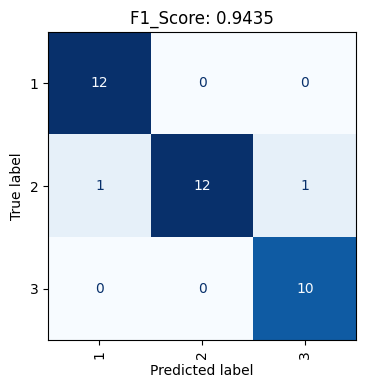

In [71]:
cm = confusion_matrix(y_test, y_predict.argmax(axis=1))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1,2,3])

fig, ax = plt.subplots(figsize = (4,4))

disp.plot(ax=ax, cmap='Blues',  xticks_rotation = 'vertical', colorbar=False)
# Disable the grid
ax.grid(False)
ax.set_title(f"F1_Score: {f1_score(y_test, y_predict.argmax(axis=1), average='weighted'):0.4f}")
plt.show()